Simple first net

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from pathlib import Path

In [ ]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv", index_col=0)

In [16]:
df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,direct_ownership,transaction_month,...,742,743,744,745,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare
0,ANTP,INZER DEBORAH,2009-01-29,D,False,True,False,False,1,1,...,3.710100,3.880000,3.880000,3.880000,3.819900,3.650000,3.630000,3.640000,12.788151,0.960514
2,HBNC,NEFF JAMES D,2009-01-30,D,False,True,False,False,1,1,...,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302,19.211383,2.881239
3,HBNC,NEFF JAMES D,2009-01-30,D,False,True,False,False,1,1,...,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302,17.589295,2.880981
4,WLFC,JACOBS SY,2009-01-28,I,False,False,True,False,0,1,...,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,14.894602,2.406397
5,WLFC,JACOBS SY,2009-01-29,I,False,False,True,False,0,1,...,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,11.336428,2.415061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,D,True,True,False,False,1,12,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,5.234962,2.801416
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,D,True,True,False,False,1,12,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,13.662286,2.804696
252707,SFBC,STILWELL JOSEPH,2023-12-28,I,False,False,True,False,0,12,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,2.290256,4.433340
252708,SFBC,STILWELL JOSEPH,2023-12-29,I,False,False,True,False,0,12,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,10.187822,4.442684


In [22]:
df["target"] = (
    df['10'] >
    df['0']
    ).astype('int8')
df["target"].sum()


np.int64(81026)

In [23]:
num_cols = df.select_dtypes(include="number").columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns="transaction_month")
df_numeric

,direct_ownership,month_sin,month_cos,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,target
0,1,5.000000e-01,0.866025,-0.491450,0,-0.577369,0,1,12.788151,0.960514,1
2,1,5.000000e-01,0.866025,-0.405462,0,-0.495864,0,1,19.211383,2.881239,0
3,1,5.000000e-01,0.866025,-0.405462,0,-0.495864,0,1,17.589295,2.880981,0
4,0,5.000000e-01,0.866025,-0.395908,0,-0.495864,0,0,14.894602,2.406397,0
5,0,5.000000e-01,0.866025,-0.395908,0,-0.414360,0,0,11.336428,2.415061,0
...,...,...,...,...,...,...,...,...,...,...,...
252705,1,-2.449294e-16,1.000000,0.325435,1,-0.577369,0,0,5.234962,2.801416,1
252706,1,-2.449294e-16,1.000000,0.325435,1,-0.577369,0,1,13.662286,2.804696,1
252707,0,-2.449294e-16,1.000000,2.546790,1,-0.577369,1,0,2.290256,4.433340,0
252708,0,-2.449294e-16,1.000000,2.546790,1,-0.495864,1,0,10.187822,4.442684,0


In [24]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5639 - loss: 0.6891
Epoch 2/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5780 - loss: 0.6775
Epoch 3/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5791 - loss: 0.6748
Epoch 4/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5827 - loss: 0.6722
Epoch 5/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5844 - loss: 0.6705
Epoch 6/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5862 - loss: 0.6683
Epoch 7/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5894 - loss: 0.6664
Epoch 8/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5914 - loss: 0.6643
Epoch 9/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5919 - loss: 0.6628
Epoch 10/10
2961/2961 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5947 - loss: 0.6609


In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

c:\Users\tsymb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.5659 - loss: 0.6907 - val_accuracy: 0.5755 - val_loss: 0.6785
Epoch 2/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5752 - loss: 0.6799 - val_accuracy: 0.5793 - val_loss: 0.6767
Epoch 3/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5762 - loss: 0.6792 - val_accuracy: 0.5773 - val_loss: 0.6771
Epoch 4/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5750 - loss: 0.6787 - val_accuracy: 0.5792 - val_loss: 0.6770
Epoch 5/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5773 - loss: 0.6780 - val_accuracy: 0.5789 - val_loss: 0.6770
Epoch 6/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5778 - loss: 0.6779 - val_accuracy: 0.5786 - val_loss: 0.6770
Epoch 7/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5782 - loss: 0.6770 - val_accuracy: 0.5775 - val_loss: 0.6746
Epoch 8/50
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.5774 - loss: 0

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

1459/1459 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5818 - loss: 0.6794
Test accuracy: 0.5817990899085999


In [31]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

1459/1459 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", auc)

[[ 1138 18873]
 [  639 26007]]
              precision    recall  f1-score   support

           0       0.64      0.06      0.10     20011
           1       0.58      0.98      0.73     26646

    accuracy                           0.58     46657
   macro avg       0.61      0.52      0.42     46657
weighted avg       0.61      0.58      0.46     46657

ROC AUC: 0.5762050914404943


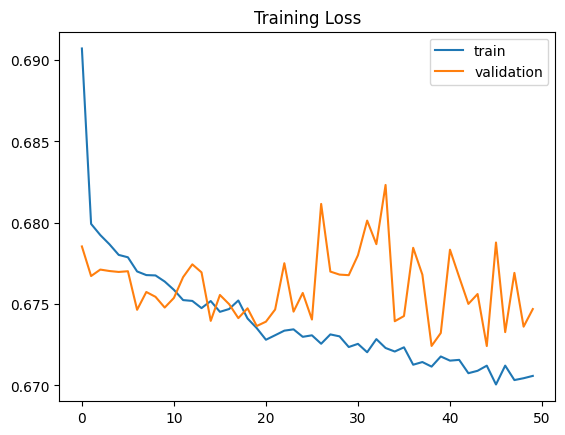

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["train","validation"])
plt.title("Training Loss")
plt.show()

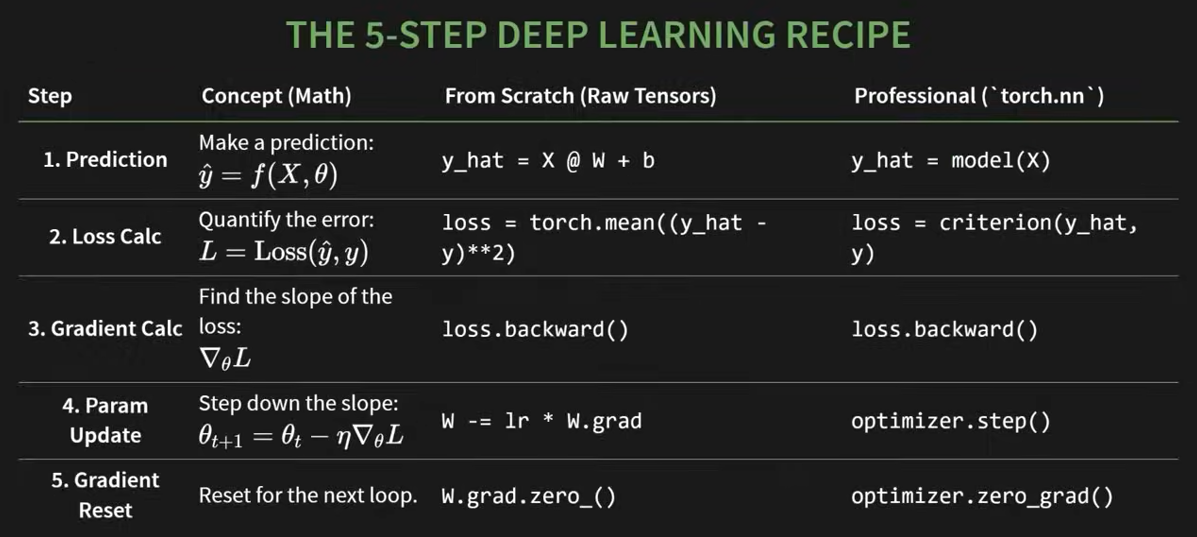